In [3]:
import pandas as pd
df = pd.read_csv('/content/Superstore sales dataset.csv', encoding='latin1')

# Verify the dates are there now
if 'Order Date' in df.columns:
    print("Success! Dates found. We can proceed with the full project.")
else:
    print("Still missing. Let's look at the columns again:", df.columns.tolist())

Success! Dates found. We can proceed with the full project.


In [4]:
# Check for missing values in each column
print(df.isnull().sum())

# Check for duplicate rows
print(f"Duplicate rows: {df.duplicated().sum()}")

ï»¿Row ID        0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64
Duplicate rows: 0


In [6]:
# Convert Order Date and Ship Date to datetime objects
df['Order Date'] = pd.to_datetime(df['Order Date'], format='%d/%m/%Y')
df['Ship Date'] = pd.to_datetime(df['Ship Date'], format='%d/%m/%Y')

# Create a new column: Shipping Days
df['Days to Ship'] = (df['Ship Date'] - df['Order Date']).dt.days

print(df[['Order Date', 'Ship Date', 'Days to Ship']].head())

  Order Date  Ship Date  Days to Ship
0 2016-11-08 2016-11-11             3
1 2016-11-08 2016-11-11             3
2 2016-06-12 2016-06-16             4
3 2015-10-11 2015-10-18             7
4 2015-10-11 2015-10-18             7


In [8]:
df['Order Month'] = df['Order Date'].dt.month_name()
df['Order Year'] = df['Order Date'].dt.year
df['Order Day of Week'] = df['Order Date'].dt.day_name()

In [9]:
# Categorize each sale
df['Profit Status'] = df['Profit'].apply(lambda x: 'Profit' if x > 0 else 'Loss')

# See the breakdown
print(df['Profit Status'].value_counts())

Profit Status
Profit    8058
Loss      1936
Name: count, dtype: int64


In [10]:
# 1. Remove leading/trailing spaces from column names
df.columns = df.columns.str.strip()

# 2. Rename columns to match our project (Modify the right side to match YOUR list)
# Example: If your column is 'order_date', change it to 'Order Date'
# df = df.rename(columns={'order_date': 'Order Date', 'ship_date': 'Ship Date'})

# 3. Let's verify again
print(df.columns)

Index(['ï»¿Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit',
       'Days to Ship', 'Order Month', 'Order Year', 'Order Day of Week',
       'Profit Status'],
      dtype='object')


In [11]:
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

In [12]:
df['Ship Days'] = (df['Ship Date'] - df['Order Date']).dt.days

In [13]:
df['Order Year'] = df['Order Date'].dt.year
df['Order Month'] = df['Order Date'].dt.month_name()

In [14]:
# Calculate high-level metrics
total_sales = df['Sales'].sum()
total_profit = df['Profit'].sum()
avg_shipping_days = df['Ship Days'].mean()

print(f"Total Sales: ${total_sales:,.2f}")
print(f"Total Profit: ${total_profit:,.2f}")
print(f"Average Days to Ship: {avg_shipping_days:.2f} days")

Total Sales: $2,297,200.86
Total Profit: $286,397.02
Average Days to Ship: 3.96 days


In [15]:
# Group by Category and Sub-Category to see Profitability
category_analysis = df.groupby(['Category', 'Sub-Category'])[['Sales', 'Profit']].sum().sort_values(by='Profit', ascending=False)

print(category_analysis)

                                    Sales      Profit
Category        Sub-Category                         
Technology      Copiers       149528.0300  55617.8249
                Phones        330007.0540  44515.7306
                Accessories   167380.3180  41936.6357
Office Supplies Paper          78479.2060  34053.5693
                Binders       203412.7330  30221.7633
Furniture       Chairs        328449.1030  26590.1663
Office Supplies Storage       223843.6080  21278.8264
                Appliances    107532.1610  18138.0054
Furniture       Furnishings    91705.1640  13059.1436
Office Supplies Envelopes      16476.4020   6964.1767
                Art            27118.7920   6527.7870
                Labels         12486.3120   5546.2540
Technology      Machines      189238.6310   3384.7569
Office Supplies Fasteners       3024.2800    949.5182
                Supplies       46673.5380  -1189.0995
Furniture       Bookcases     114879.9963  -3472.5560
                Tables      

In [16]:
# Group by Month and Year
monthly_sales = df.groupby(['Order Year', 'Order Month'])['Sales'].sum().reset_index()

# Sort them correctly (January to December)
months = ["January", "February", "March", "April", "May", "June",
          "July", "August", "September", "October", "November", "December"]
monthly_sales['Order Month'] = pd.Categorical(monthly_sales['Order Month'], categories=months, ordered=True)
monthly_sales = monthly_sales.sort_values('Order Month')

print(monthly_sales)

    Order Year Order Month        Sales
16        2015     January   18174.0756
28        2016     January   18542.4910
4         2014     January   14236.8950
40        2017     January   43971.3740
27        2016    February   22978.8150
3         2014    February    4519.8920
39        2017    February   20301.1334
15        2015    February   11951.4110
7         2014       March   55691.0090
43        2017       March   58872.3528
19        2015       March   38726.2520
31        2016       March   51715.8750
24        2016       April   38750.0390
36        2017       April   36521.5361
0         2014       April   28295.3450
12        2015       April   34195.2085
44        2017         May   44261.1102
8         2014         May   23648.2870
20        2015         May   30131.6865
32        2016         May   56987.7280
18        2015        June   24797.2920
30        2016        June   40344.5340
42        2017        June   52981.7257
6         2014        June   34595.1276


In [17]:
# See if high discounts are hurting profit
discount_impact = df.groupby('Discount')['Profit'].mean()
print(discount_impact)

Discount
0.00     66.900292
0.10     96.055074
0.15     27.288298
0.20     24.702572
0.30    -45.679636
0.32    -88.560656
0.40   -111.927429
0.45   -226.646464
0.50   -310.703456
0.60    -43.077212
0.70    -95.874060
0.80   -101.796797
Name: Profit, dtype: float64


/tmp/ipykernel_152/3926344444.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Sub-Category', y='Profit', data=df, estimator=sum, palette='RdYlGn')


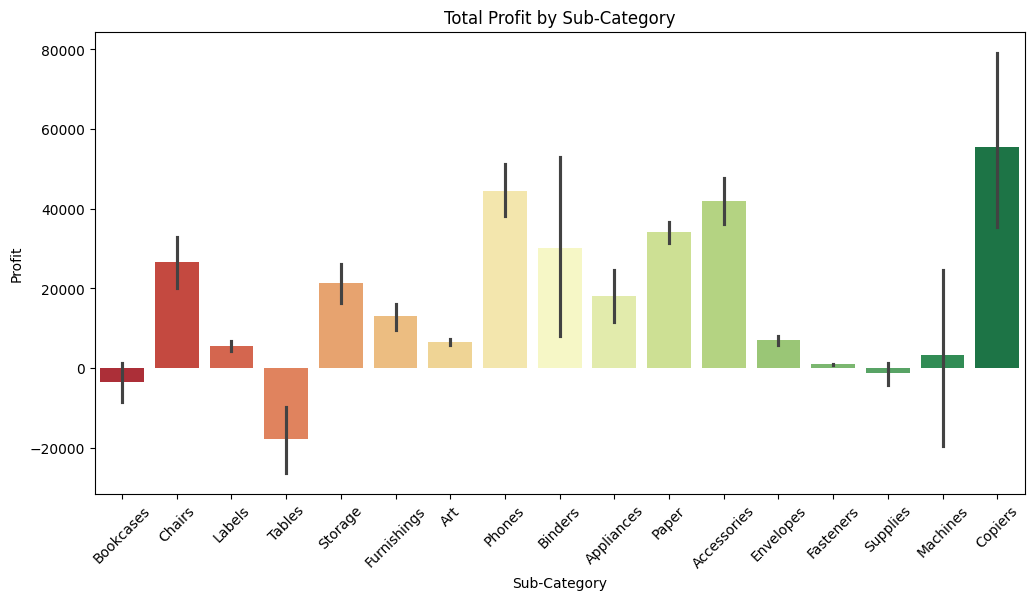

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,6))
sns.barplot(x='Sub-Category', y='Profit', data=df, estimator=sum, palette='RdYlGn')
plt.xticks(rotation=45)
plt.title('Total Profit by Sub-Category')
plt.show()

/tmp/ipykernel_152/3494216858.py:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.lineplot(x='Order Month', y='Sales', data=df, estimator=sum, ci=None, marker='o')


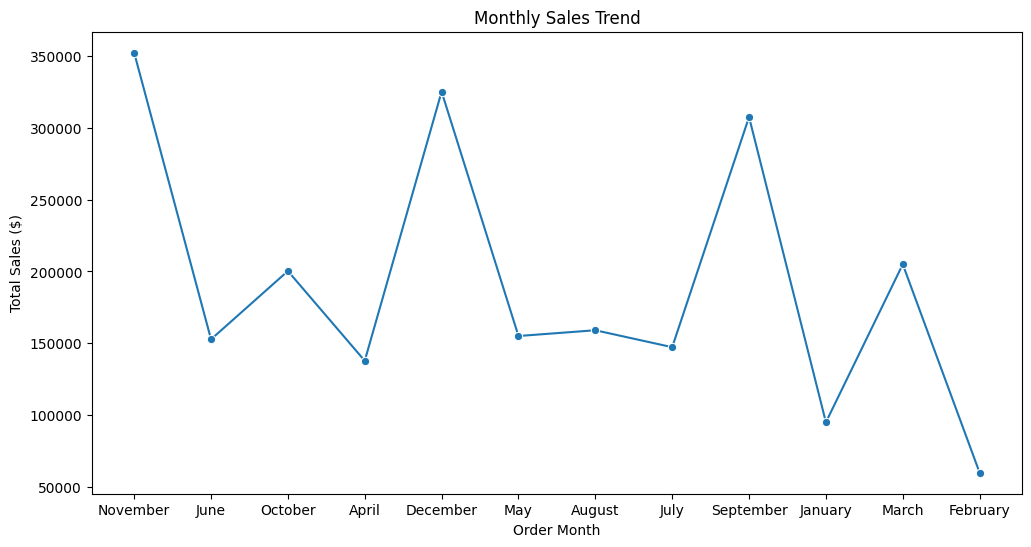

In [19]:
plt.figure(figsize=(12,6))
sns.lineplot(x='Order Month', y='Sales', data=df, estimator=sum, ci=None, marker='o')
plt.title('Monthly Sales Trend')
plt.ylabel('Total Sales ($)')
plt.show()

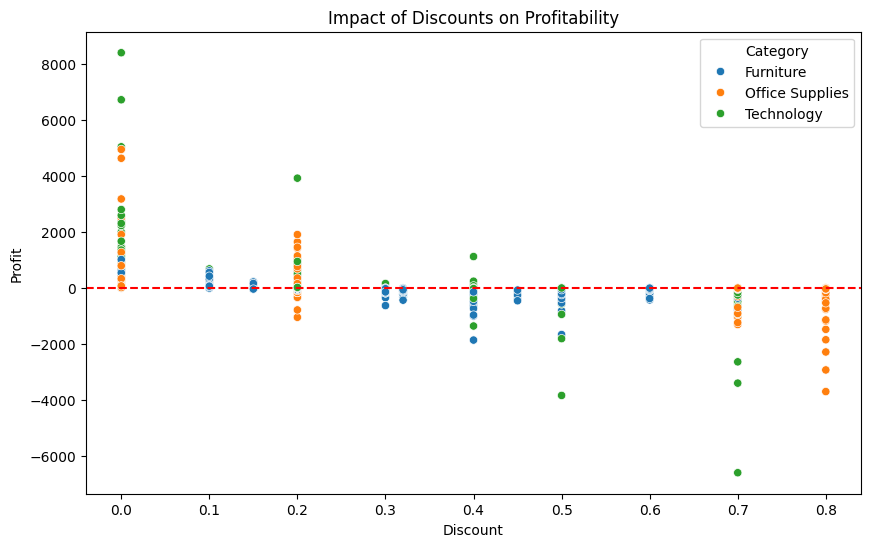

In [20]:
plt.figure(figsize=(10,6))
sns.scatterplot(x='Discount', y='Profit', data=df, hue='Category')
plt.title('Impact of Discounts on Profitability')
plt.axhline(0, color='red', linestyle='--') # Line at zero profit
plt.show()